# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [ ]:
%pip install torch tqdm assertpy scikit-learn pandas matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for assertpy: filename=assertpy-1.1-py3-none-any.whl size=42897 sha256=b68c77ebb90093d377e5566b6c9a71eb052f195c8563399c5990059883b4d8fc
  Stored in directory: /root/.cache/pip/wheels/e9/a6/9e/a5cead15269b79ab7ebf051cfc3f7adcbd5a880e683e94736a
Successfully built assertpy


In [3]:
!tar -xf waf-urls.tar.xz #<--- To Unzip data

## 1. Data Loading

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')

Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [6]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    ## Implement N-gram generation
    # - Pad (n-1) start_symbols before text
    # - Pad n end_symbols after text
    # - Return generator of N-grams
    padded = start_symbol * (n-1) + text + end_symbol * (n)
    return (padded[i:i+n] for i in range(len(padded)-n+1))

# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [7]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}

    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ## [ TODO 2.1 ] Count N-gram occurrences
            ngram_count[ngram] = ngram_count.get(ngram, 0) + 1

    n2i, i2n = {}, []
    n_rare = 0

    print('Building mapping...')
    for ngram, count in tqdm(ngram_count.items()):
        ## [ TODO 2.2 ] Build mapping (only if count >= rare_threshold)
        # - Add to n2i and i2n if frequent
        # - Track n_rare for rare N-grams
        if count >= rare_threshold:
          n2i[ngram] = len(i2n)
          i2n.append(ngram)
        else:
          n_rare += 1


    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<00:00, 20100.50it/s]


Building mapping...


100%|██████████| 15/15 [00:00<00:00, 162569.92it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [8]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram+1, n_ngram+1))

    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            ## [ TODO 3.1 ] Get N-gram index (unknown_idx if not found)
            idx = n2i_mapping.get(ngram, unknown_idx)

            ## [ TODO 3.2 ] Update co-occurrence for prev neighbors in window
            for prev_idx in prev_indices:
                co_matrix[prev_idx, idx] += 1
                co_matrix[idx, prev_idx] += 1

            prev_indices.append(idx)

    print('Normalizing...')
    row_sums = co_matrix.sum(axis=1)
    ## [ TODO 3.3 ] Normalize rows to probability distributions
    for (i, j) in tqdm(list(co_matrix.keys())):
        co_matrix[i, j] /= row_sums[i]

    return co_matrix

In [9]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:02<00:00, 14795.36it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 2035728.77it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [1:06:34<00:00,  9.09it/s]


Normalizing...


100%|██████████| 22858772/22858772 [12:06<00:00, 31484.11it/s]


Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [10]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ TODO 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [12]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)

    for i, url in enumerate(urls):
        ## [ TODO 5.1 ] Pad URL to padded_len
        url = url[:padded_len] + pad_symbol * (padded_len - len(url))

        ## [ TODO 5.2 ] Convert N-grams to indices
        for j, ngram in enumerate(iter_ngrams(url, n)):
            batch[i, j] = n2i_mapping.get(ngram, unknown_idx)

    return batch

In [13]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [36]:
class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]

        ## [ TODO 6.1 ] Embedding layer (frozen, initialized with embedding_weights)
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_weights).float(), freeze=True)

        ## [ TODO 6.2 ] Conv blocks
        # conv1: embed_dim -> 20, kernel=5, padding=2
        # conv2: 20 -> 40, kernel=5, padding=2
        # conv3: 40 -> 80, kernel=5, padding=2
        # pool1: MaxPool1d(2), pool2: MaxPool1d(5), pool3: MaxPool1d(5)
        self.conv1 = nn.Conv1d(embed_dim, 20, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(20, 40, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(40, 80, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool1d(2)
        self.pool2 = nn.MaxPool1d(5)
        self.pool3 = nn.MaxPool1d(5)
        self.dropout = nn.Dropout(dropout)

        ## [ TODO 6.3 ] FC layers
        # fc1: 160 -> 16, fc2: 16 -> 1
        self.fc1 = nn.Linear(160, 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        ## [ TODO 6.4 ] Forward pass
        # Embedding -> permute -> conv blocks -> flatten -> FC -> sigmoid
        x = self.embedding(x).permute(0, 2, 1)
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.pool3(torch.relu(self.conv3(x)))
        x = self.dropout(x.flatten(1))
        x = torch.relu(self.fc1(x))
        return torch.sigmoid(self.fc2(x))

In [37]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [43]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        ## [ TODO 7 ] Training step
        # optimizer.zero_grad(), forward, loss, backward, step
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y.unsqueeze(1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += ((out > 0.5) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y.unsqueeze(1)).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [44]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=134.1015, Val Acc=134.8269
Epoch 2: Train Acc=134.0916, Val Acc=133.7772
Epoch 3: Train Acc=133.8957, Val Acc=132.6415
Epoch 4: Train Acc=133.7236, Val Acc=133.5954
Epoch 5: Train Acc=133.7036, Val Acc=132.0989
Epoch 6: Train Acc=133.6348, Val Acc=133.2504
Epoch 7: Train Acc=133.5940, Val Acc=133.2563
Epoch 8: Train Acc=133.6558, Val Acc=131.7954
Epoch 9: Train Acc=133.3592, Val Acc=133.3178
Epoch 10: Train Acc=133.5858, Val Acc=132.6766


## 6. Evaluation

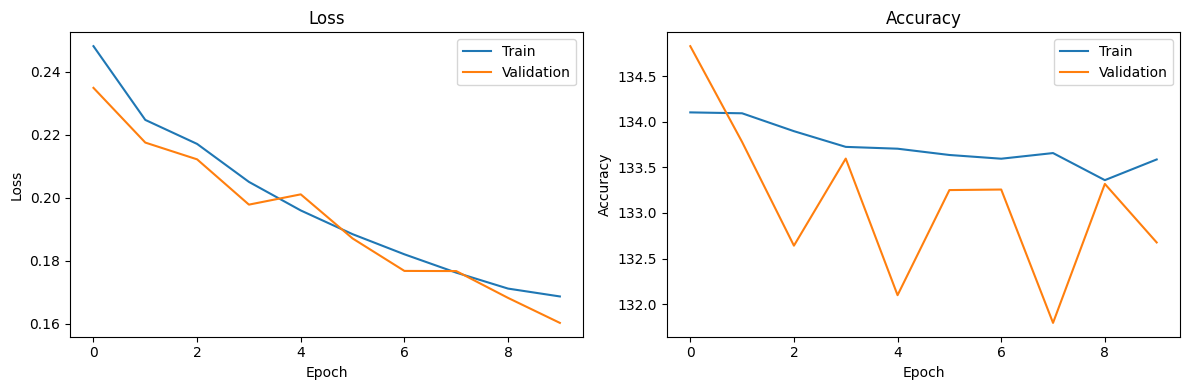

In [47]:
import matplotlib.pyplot as plt

## [ TODO 8 ] Plot loss and accuracy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['loss'], label='Train')
ax1.plot(history['val_loss'], label='Validation')
ax1.set(title='Loss', xlabel='Epoch', ylabel='Loss')
ax1.legend()

ax2.plot(history['acc'], label='Train')
ax2.plot(history['val_acc'], label='Validation')
ax2.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [49]:
from sklearn.metrics import confusion_matrix, classification_report

## [ TODO 9 ] Test evaluation
# - Create test dataset and loader
# - Predict and collect results
# - Print confusion matrix and classification report
test_dataset = URLDataset(
    urls_test, labels_test, MAX_URL_LEN, N, n2i_urls
)
test_loader = DataLoader(test_dataset, batch_size=512)

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device))
        all_preds.extend((out > 0.5).cpu().numpy())
        all_labels.extend(y.numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=['benign', 'malicious']))

[[6767  376]
 [ 527 4440]]
              precision    recall  f1-score   support

      benign       0.93      0.95      0.94      7143
   malicious       0.92      0.89      0.91      4967

    accuracy                           0.93     12110
   macro avg       0.92      0.92      0.92     12110
weighted avg       0.93      0.93      0.93     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)

**Your Answer:**
Yes. The loss decreased throughout the training process, and we ended up having final accuracy of 93%.


**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

**Your Answer:**
A large window size is not good for URL N-grams because it introduces noises by diluted local patterns. The learnable nn. Embedding layers is another compression method in this lab.


## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`